In [1]:
print("Project 5: Outfit Recommender V3")

Project 5: Outfit Recommender V3


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

In [3]:
IMAGE_FOLDER = "../images"

files = [
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Number of images:", len(files))
print(files[:5])

Number of images: 26
['#outfits #fashion #summer #summerstyle.jpg', '30 Effortlessly Chic Outfits to Copy for Summer.jpg', '5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg', 'Another Day in Denim.jpg', 'download (1).jpg']


In [4]:
def get_features(image_path, n_colors=3):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((100, 100))  # speed + consistency

    img_array = np.array(img).reshape(-1, 3)

    # Dominant colors
    kmeans = KMeans(n_clusters=n_colors, random_state=42)
    kmeans.fit(img_array)
    colors = kmeans.cluster_centers_

    # Brightness
    brightness = np.mean(img_array)

    # Contrast
    contrast = np.std(img_array)

    # Combine everything
    feature_vector = np.concatenate([
        colors.flatten(),
        [brightness, contrast]
    ])

    return feature_vector

In [5]:
all_features = []

for file in files:
    path = os.path.join(IMAGE_FOLDER, file)
    features = get_features(path)
    all_features.append(features)

all_features = np.array(all_features)

print("Raw feature shape:", all_features.shape)
print("Example raw feature:", all_features[0])

Raw feature shape: (26, 11)
Example raw feature: [182.5246646  182.57027864 178.59050568 120.1573858  116.75625208
 113.993998    36.6864564   32.53246753  30.02643785 130.0167
  61.95897369]


In [6]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(all_features)

print("Scaled feature shape:", scaled_features.shape)
print("Example scaled feature:", scaled_features[0])

Scaled feature shape: (26, 11)
Example scaled feature: [ 0.75479354  0.83847683  0.83753655 -0.34953815 -0.31064975 -0.20534331
 -1.50296998 -1.41143505 -1.30374282 -0.05290495  0.05479718]


In [7]:
style_model = KMeans(n_clusters=3, random_state=42)

style_labels = style_model.fit_predict(scaled_features)

style_names = {
    0: "Neutral / Minimal",
    1: "Dark / Streetwear",
    2: "Light / Casual"
}

print(style_labels)

for file, label in zip(files, style_labels):
    print(file, "→ Style Group", label)

[1 0 0 2 2 1 2 0 1 0 0 0 1 2 2 2 2 1 0 0 2 1 0 1 1 1]
#outfits #fashion #summer #summerstyle.jpg → Style Group 1
30 Effortlessly Chic Outfits to Copy for Summer.jpg → Style Group 0
5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg → Style Group 0
Another Day in Denim.jpg → Style Group 2
download (1).jpg → Style Group 2
download (2).jpg → Style Group 1
download (3).jpg → Style Group 2
download (4).jpg → Style Group 0
download (5).jpg → Style Group 1
download.jpg → Style Group 0
Elegant Spring Outfit Inspo _ Effortlessly Chic Cafe Baddie Look 2026.jpg → Style Group 0
Elegant Street Style _ Fashion Essentials.jpg → Style Group 0
Ellie (@slipintostyle) • Instagram photos and videos.jpg → Style Group 1
example_output.png → Style Group 2
Find Out Where To Get The Top.jpg → Style Group 2
Jordan Clarkson Outfits.jpg → Style Group 2
Jordan Clarkson.jpg → Style Group 2
LAURA JADE NUDE HIGH WAISTED MIDI SKIRT WITH BUTTON SIDE SPLIT.jpg → Style Group 1
lewis hamilton.jpg → Style 

C:\Users\ousama\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [8]:
def recommend_similar_outfits(image_path, top_n=3):
    # Extract raw features from input image
    new_feature = get_features(image_path)

    # Scale the new image using the SAME scaler
    new_feature_scaled = scaler.transform([new_feature])

    # Compare input image with all dataset images using scaled features
    similarities = cosine_similarity(new_feature_scaled, scaled_features)[0]

    # Find the style group of the input image
    input_filename = os.path.basename(image_path)

    if input_filename in files:
        input_index = files.index(input_filename)
        input_style = style_labels[input_index]
    else:
        input_style = style_model.predict(new_feature_scaled)[0]

    print("Input style:", style_names[input_style])

    # Sort from highest similarity to lowest
    sorted_indexes = similarities.argsort()[::-1]

    shown = 0

    for index in sorted_indexes:
        file = files[index]

        # Skip same image
        if file == input_filename:
            continue

        # Only recommend images from same style group
        if style_labels[index] != input_style:
            continue

        score = similarities[index]

        img_path = os.path.join(IMAGE_FOLDER, file)
        img = Image.open(img_path).convert("RGB")

        print(f"{file} → similarity: {score:.3f}")

        plt.imshow(img)
        plt.title(f"{style_names[input_style]}\n{file}\nSimilarity: {score:.3f}")
        plt.axis("off")
        plt.show()

        shown += 1

        if shown >= top_n:
            break

Input style: Dark / Streetwear
LAURA JADE NUDE HIGH WAISTED MIDI SKIRT WITH BUTTON SIDE SPLIT.jpg → similarity: 0.956


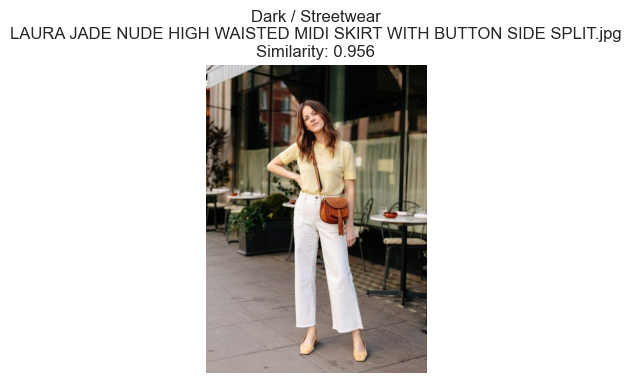

download (5).jpg → similarity: 0.946


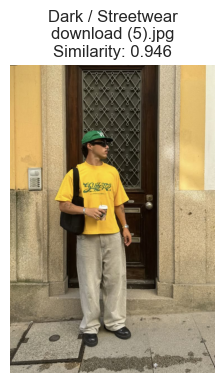

Rose.jpg → similarity: 0.823


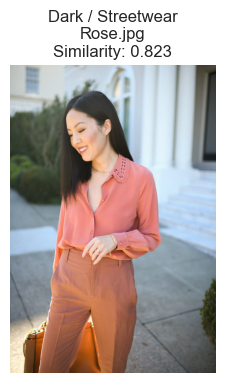

In [9]:
test_image = os.path.join(IMAGE_FOLDER, files[0])

recommend_similar_outfits(test_image, top_n=3)